In [43]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [44]:
df = pd.read_csv("master_dataset_final.csv")
df.head()

,raceId,year,round,circuitId,race_name,circuit_name,location,country,driverStandingsId,driverId,...,avg_time_per_stop,constructor_avg_pit,constructor_circuit_avg_finish,driver_circuit_experience,driver_qualifying_form,team_race_avg_finish,rel_teammate_performance,driver_teammate_diff_form,driver_teammate_diff_historic,driver_consistency_std
0,989,2018,1,1,Australian Grand Prix,Albert Park Grand Prix Circuit,Melbourne,Australia,68610,1,...,21.821,24.871523,10.0,0,10.00,10.5,-8.5,0.00,NaN,2.0
1,990,2018,2,3,Bahrain Grand Prix,Bahrain International Circuit,Sakhir,Bahrain,68690,1,...,24.302,24.871523,10.0,0,1.00,10.5,-8.5,-8.50,-8.50,2.0
2,991,2018,3,17,Chinese Grand Prix,Shanghai International Circuit,Shanghai,China,68670,1,...,22.464,21.821000,10.0,0,2.50,10.5,-8.5,-8.50,-8.50,0.0
3,992,2018,4,73,Azerbaijan Grand Prix,Baku City Circuit,Baku,Azerbaijan,68710,1,...,20.377,22.142500,10.0,0,3.00,10.5,-9.5,-8.50,-8.50,0.0
4,993,2018,5,4,Spanish Grand Prix,Circuit de Barcelona-Catalunya,Montmeló,Spain,68730,1,...,22.085,21.554000,10.0,0,2.75,10.5,-9.5,-8.75,-8.75,0.5


In [45]:
print(df.columns.tolist())

['raceId', 'year', 'round', 'circuitId', 'race_name', 'circuit_name', 'location', 'country', 'driverStandingsId', 'driverId', 'points', 'final_position', 'wins', 'year_y', 'code', 'forename', 'surname', 'nationality', 'driver_name', 'constructorStandingsId', 'constructorId', 'points_constructor', 'constructor_final_position', 'wins_constructor', 'qualifying_position', 'q1', 'q2', 'q3', 'pit_stop_count', 'pit_duration', 'avg_lap_time', 'total_laps', 'pos_ratio', 'driver_form', 'driver_circuit_performance', 'driver_circuit_performance_5', 'avg_time_per_stop', 'constructor_avg_pit', 'constructor_circuit_avg_finish', 'driver_circuit_experience', 'driver_qualifying_form', 'team_race_avg_finish', 'rel_teammate_performance', 'driver_teammate_diff_form', 'driver_teammate_diff_historic', 'driver_consistency_std']


In [46]:
print(df.dtypes)

raceId                              int64
year                                int64
round                               int64
circuitId                           int64
race_name                          object
circuit_name                       object
location                           object
country                            object
driverStandingsId                   int64
driverId                            int64
points                            float64
final_position                      int64
wins                                int64
year_y                              int64
code                               object
forename                           object
surname                            object
nationality                        object
driver_name                        object
constructorStandingsId              int64
constructorId                       int64
points_constructor                float64
constructor_final_position          int64
wins_constructor                  

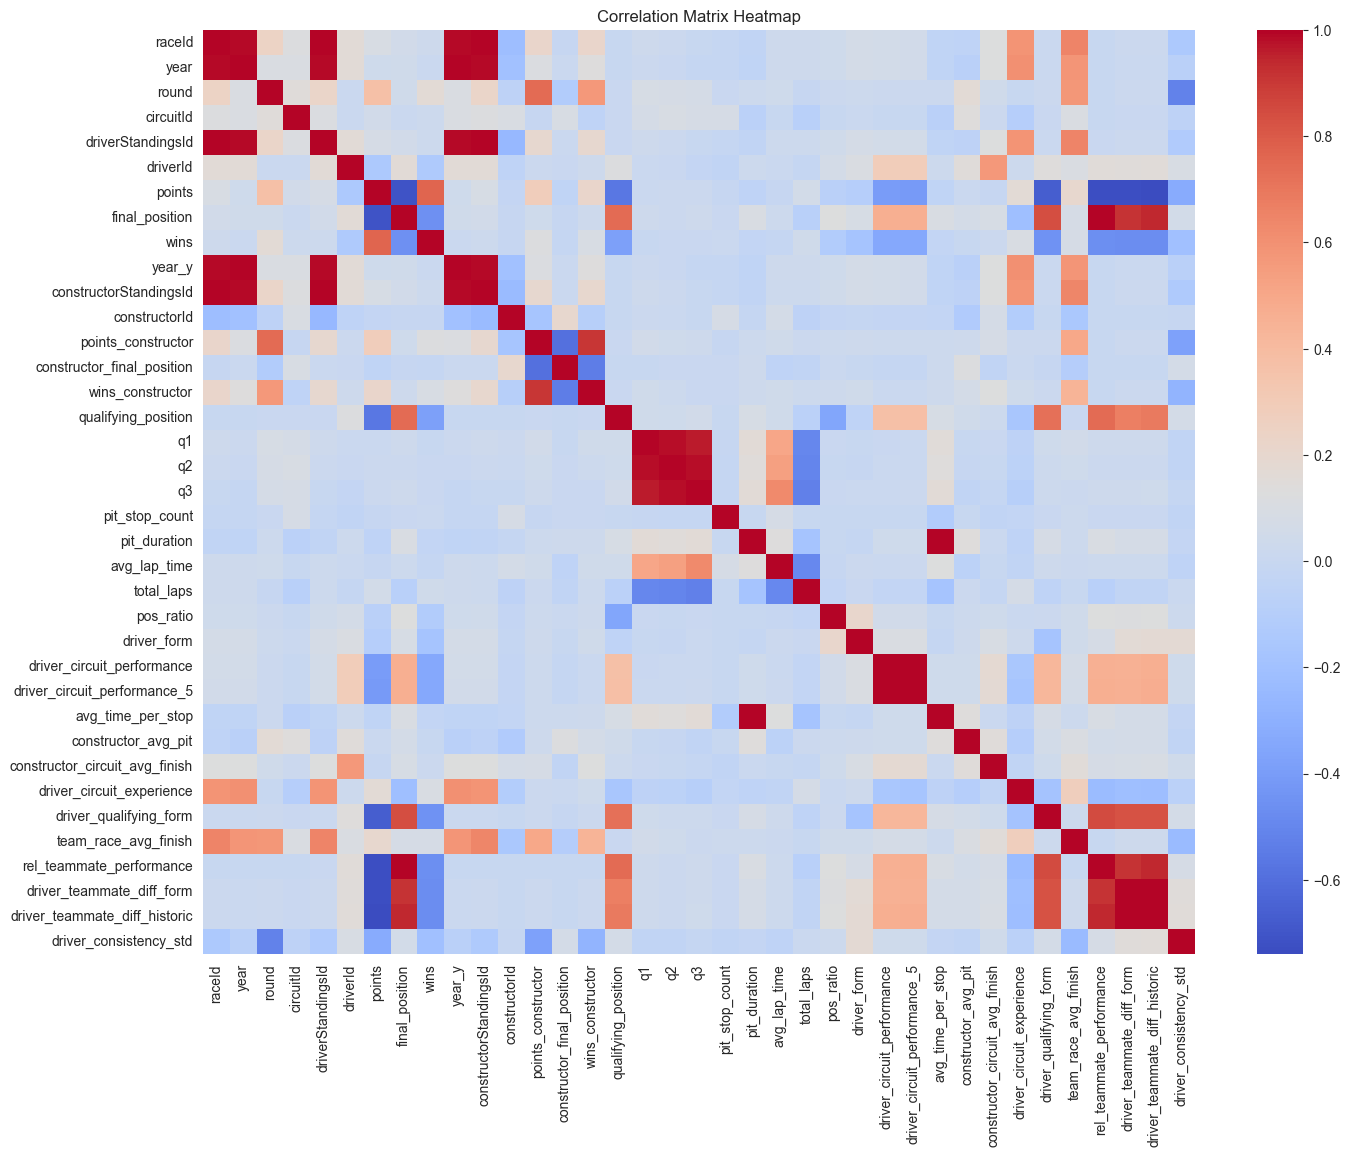

driverStandingsId           constructorStandingsId           0.999095
driver_circuit_performance  driver_circuit_performance_5     0.998807
final_position              rel_teammate_performance         0.997109
raceId                      constructorStandingsId           0.997080
                            driverStandingsId                0.996165
pit_duration                avg_time_per_stop                0.993541
raceId                      year                             0.989574
year                        constructorStandingsId           0.989318
driverStandingsId           year_y                           0.988386
year                        driverStandingsId                0.988386
q2                          q3                               0.980918
q1                          q2                               0.980334
                            q3                               0.963589
final_position              driver_teammate_diff_historic    0.943163
rel_teammate_perform

In [47]:

#corr matrix of numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr = numeric_df.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title("Correlation Matrix Heatmap")
plt.show()
#extracting strong corr
corr_pairs = corr.unstack()
#drop self corr
corr_pairs = corr_pairs[corr_pairs != 1.0]
# drop duplicates
corr_pairs = corr_pairs.drop_duplicates()
#filter correlations with corr >=0.9
strong_corr = corr_pairs[ corr_pairs.abs() >= 0.9 ].sort_values(ascending=False)
strong_corr



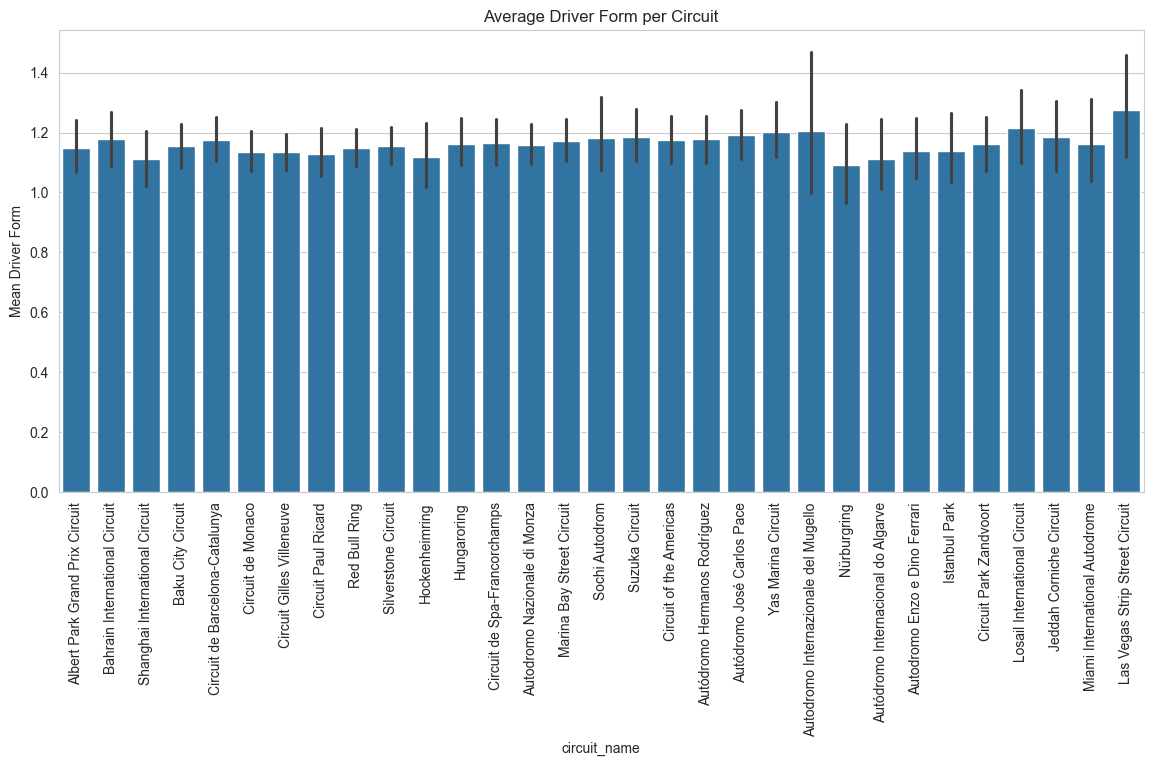

In [48]:
plt.figure(figsize=(14,6))
sns.barplot(data=df, x="circuit_name", y="driver_form", estimator="mean")
plt.xticks(rotation=90)
plt.title("Average Driver Form per Circuit")
plt.ylabel("Mean Driver Form") #the lower it is the better
plt.show()


driver performance trend for top 5 drivers 


/var/folders/m_/5_wpx3f50dzgv9_z8p716r3r0000gn/T/ipykernel_1934/1416764874.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=subset, x='year', y='driver_form', hue='driver_name', marker='o', ci=None)


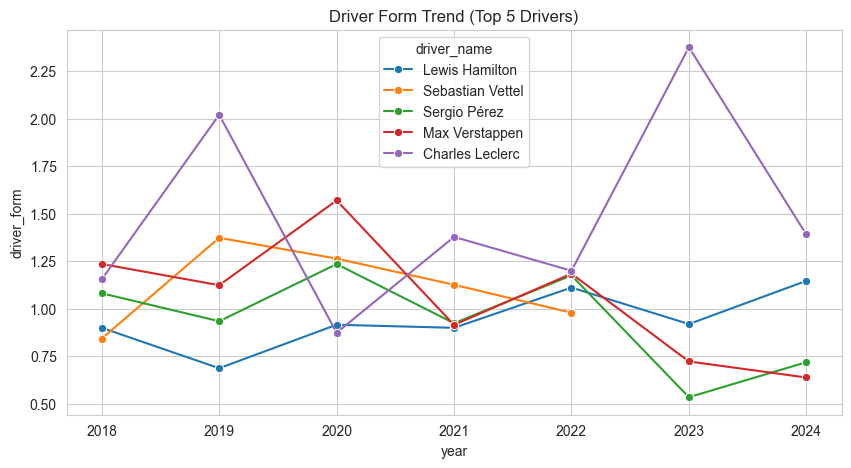

In [49]:

top_drivers = (df.groupby('driver_name')['wins'].sum().sort_values(ascending=False).head(5).index)

subset = df[df['driver_name'].isin(top_drivers)]

plt.figure(figsize=(10,5))
sns.lineplot(data=subset, x='year', y='driver_form', hue='driver_name', marker='o', ci=None)
plt.title("Driver Form Trend (Top 5 Drivers)")
plt.show()


driver performance on a circuit. This focuses on one circuit at a time. change the target_circuit to find trend on different circuits

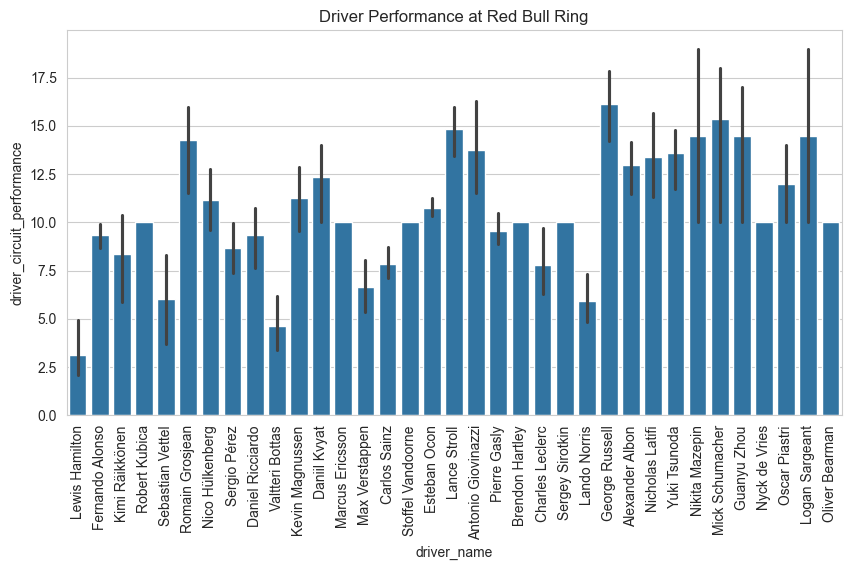

In [50]:

target_circuit = "Red Bull Ring"  
subset = df[df['circuit_name'] == target_circuit]

plt.figure(figsize=(10,5))
sns.barplot(data=subset, x='driver_name', y='driver_circuit_performance')
plt.xticks(rotation=90)
plt.title(f"Driver Performance at {target_circuit}")
plt.show()


what matters the most for this specific circuit

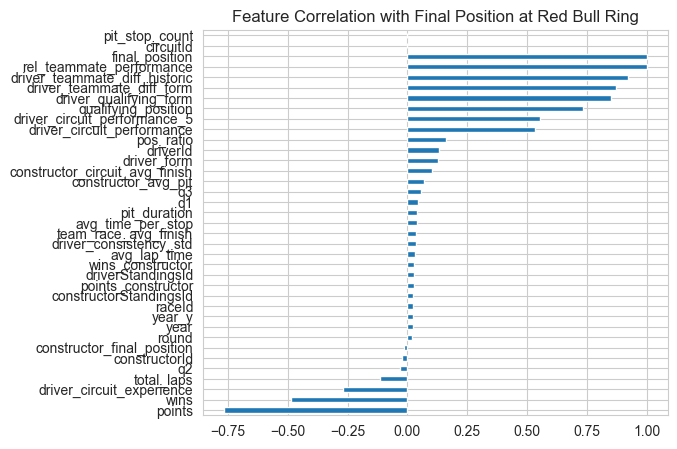

In [51]:
target_circuit = "Red Bull Ring"

subset = df[df['circuit_name'] == target_circuit]

numeric = subset.select_dtypes(include='number')
circuit_corr = numeric.corr()['final_position'].sort_values()

plt.figure(figsize=(6,5))
circuit_corr.plot(kind='barh')
plt.title(f"Feature Correlation with Final Position at {target_circuit}")
plt.show()


Team dominance of top 3 constructors

/var/folders/m_/5_wpx3f50dzgv9_z8p716r3r0000gn/T/ipykernel_1934/1215025088.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=subset, x='year', y='constructor_final_position', hue='constructorId', marker='o', ci=None, palette='Dark2')


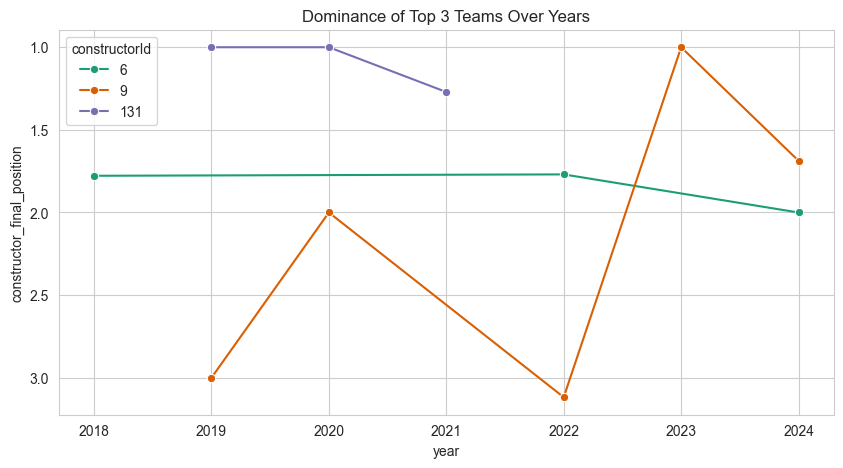

In [52]:
top_teams = (df.groupby('constructorId')['wins_constructor'].sum().sort_values(ascending=False).head(3).index)

subset = df[df['constructorId'].isin(top_teams)]

plt.figure(figsize=(10,5))
sns.lineplot(data=subset, x='year', y='constructor_final_position', hue='constructorId', marker='o', ci=None, palette='Dark2')
plt.gca().invert_yaxis()
plt.title("Dominance of Top 3 Teams Over Years")
plt.show()


team wins per year (top 3 teams)

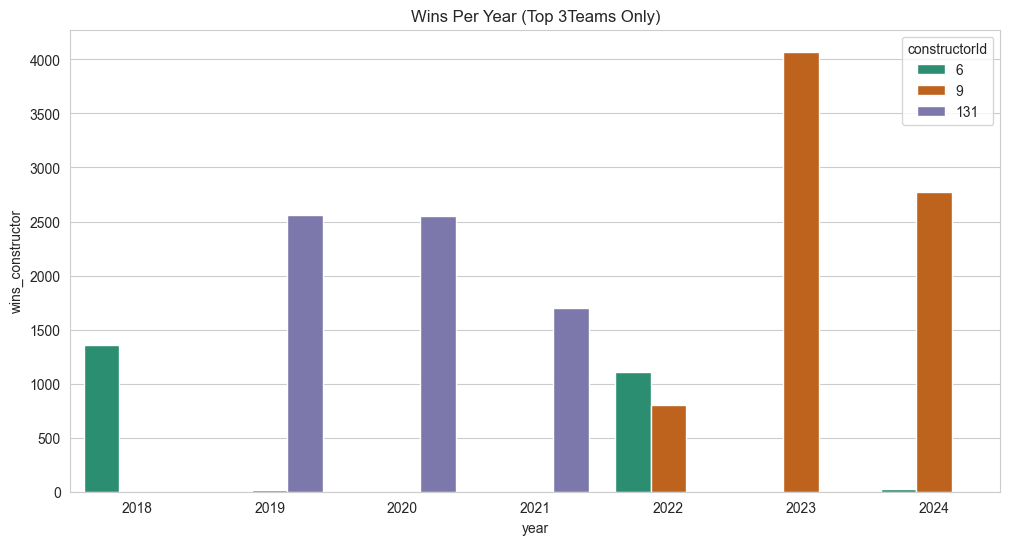

In [53]:
wins_by_team = df.groupby(['year', 'constructorId'])['wins_constructor'].sum().reset_index()
wins_by_team = wins_by_team[wins_by_team['constructorId'].isin(top_teams)]

plt.figure(figsize=(12,6))
sns.barplot(data=wins_by_team, x='year', y='wins_constructor', hue='constructorId',palette='Dark2')
plt.title("Wins Per Year (Top 3Teams Only)")
plt.show()


teammate performance, change the team manually by changing variable team
this helps us identify patterns like who is more consistent/dominant within a single team

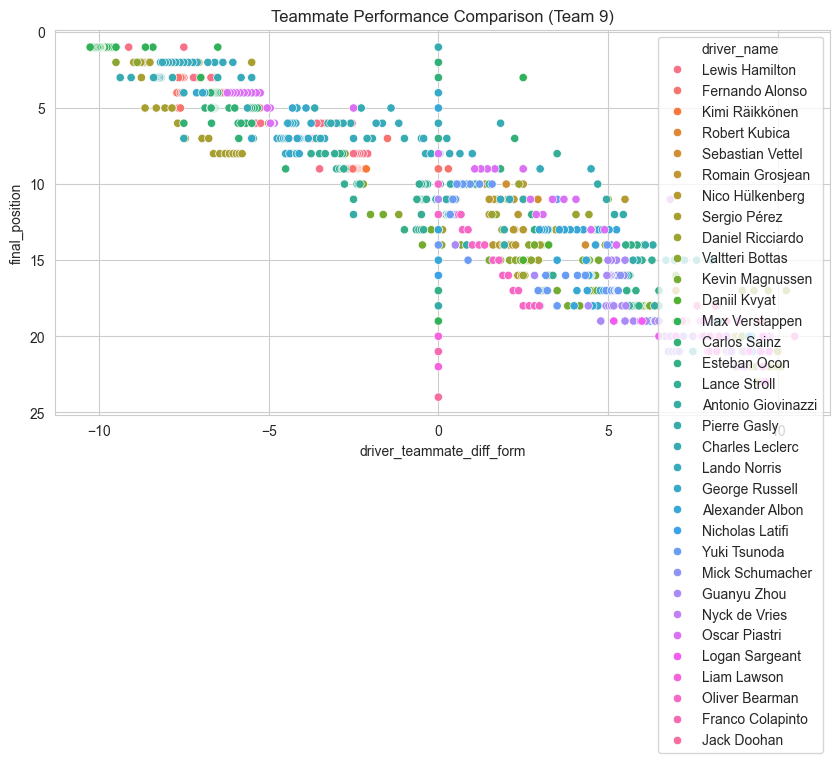

In [ ]:
team = top_teams[0]  
subset = df[df['constructorId'] == team]

plt.figure(figsize=(10,5))
sns.scatterplot(data=subset,x='driver_teammate_diff_form', y='final_position',hue='driver_name')
plt.gca().invert_yaxis()
plt.title(f"Teammate Performance Comparison (Team {team})")
plt.show()


features strongly correlated with final position

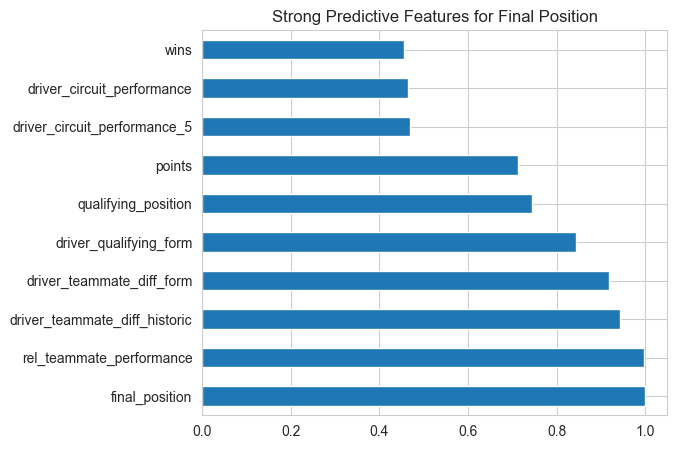

In [55]:
numeric = df.select_dtypes(include='number')
corr = numeric.corr()['final_position'].abs().sort_values(ascending=False)
strong = corr[corr > 0.3]

plt.figure(figsize=(6,5))
strong.plot(kind='barh')
plt.title("Strong Predictive Features for Final Position")
plt.show()


plot to show how qualifying position effects final position
the red trend line shows how higher qualifying positions lead to lower higher final positions.

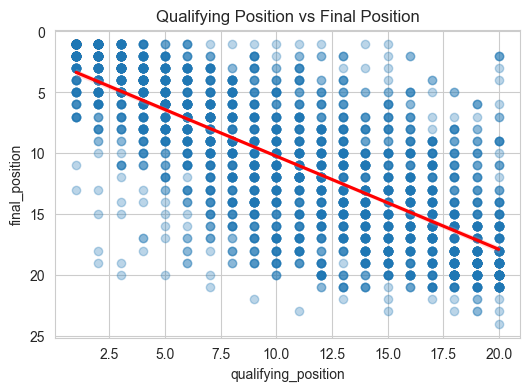

In [56]:
plt.figure(figsize=(6,4))

sns.regplot(
    data=df, 
    x='qualifying_position', 
    y='final_position', 
    scatter_kws={'alpha':0.3}, 
    line_kws={'color':'red'}    
)

plt.gca().invert_yaxis() 
plt.title("Qualifying Position vs Final Position")
plt.show()
